## Model Training


In [44]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import warnings

#### Import the CSV Data as Pandas DataFrame

In [45]:
df=pd.read_csv('Dataset/Cleaned_Data.csv')

In [46]:
df.head()

,transaction_id,customer_id,transaction_amount,payment_method,device_type,location,merchant_category,is_international,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,Transaction_Date,Transaction_Month,Transaction_Year
0,1,20953,56.31,Debit Card,Tablet,Canada,Fashion,0,1054,0,0,0,1,0,1,0,Medium,4,3,2026
1,2,24133,20.35,Credit Card,Tablet,India,Electronics,0,97,0,0,0,0,0,0,0,Low,9,3,2026
2,3,7165,48.72,Debit Card,Tablet,UK,Travel,0,779,1,0,0,0,0,0,0,Medium,1,1,2026
3,4,19310,153.62,Debit Card,Mobile,Australia,Fashion,0,286,1,1,0,1,0,1,1,High,9,12,2025
4,5,25019,115.32,PayPal,Mobile,India,Gaming,0,866,0,0,0,1,0,0,0,Low,9,11,2025


#### Preparing X and Y variables

In [47]:
X = df.drop(columns=['fraud_risk'],axis=1)

In [48]:
X.head()

,transaction_id,customer_id,transaction_amount,payment_method,device_type,location,merchant_category,is_international,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,Transaction_Date,Transaction_Month,Transaction_Year
0,1,20953,56.31,Debit Card,Tablet,Canada,Fashion,0,1054,0,0,0,1,0,1,0,4,3,2026
1,2,24133,20.35,Credit Card,Tablet,India,Electronics,0,97,0,0,0,0,0,0,0,9,3,2026
2,3,7165,48.72,Debit Card,Tablet,UK,Travel,0,779,1,0,0,0,0,0,0,1,1,2026
3,4,19310,153.62,Debit Card,Mobile,Australia,Fashion,0,286,1,1,0,1,0,1,1,9,12,2025
4,5,25019,115.32,PayPal,Mobile,India,Gaming,0,866,0,0,0,1,0,0,0,9,11,2025


In [49]:
y=df['fraud_risk']

In [50]:
y.head()

0    Medium
1       Low
2    Medium
3      High
4       Low
Name: fraud_risk, dtype: object

In [51]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [53]:
X = preprocessor.fit_transform(X)

In [54]:
X.shape

(100000, 35)

In [55]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((80000, 35), (20000, 35))

#### Create an Evaluate Function to give all metrics after model Training

In [56]:
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return accuracy, precision, recall, f1

In [57]:
models = {
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()

}

model_list = []


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    
    acc_train, prec_train, rec_train, f1_train = evaluate_model(y_train, y_train_pred)
    acc_test, prec_test, rec_test, f1_test = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("Accuracy:", acc_train)
    print("Precision:", prec_train)
    print("Recall:", rec_train)
    print("F1 Score:", f1_train)

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("Accuracy:", acc_test)
    print("Precision:", prec_test)
    print("Recall:", rec_test)
    print("F1 Score:", f1_test)
    
    
    print('='*35)
    print('\n')

K-Neighbors Classifier
Model performance for Training set
Accuracy: 0.860075
Precision: 0.8615059568963838
Recall: 0.860075
F1 Score: 0.8601351345967388
----------------------------------
Model performance for Test set
Accuracy: 0.7893
Precision: 0.7908440776979478
Recall: 0.7893
F1 Score: 0.7893543263575822


Decision Tree
Model performance for Training set
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
----------------------------------
Model performance for Test set
Accuracy: 0.7659
Precision: 0.7660120265100643
Recall: 0.7659
F1 Score: 0.7659424365412371


Random Forest Classifier
Model performance for Training set
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
----------------------------------
Model performance for Test set
Accuracy: 0.80705
Precision: 0.8157660306803577
Recall: 0.80705
F1 Score: 0.8068926834603903


XGBClassifier
Model performance for Training set
Accuracy: 0.88215
Precision: 0.890281403843459
Recall: 0.88215
F1 Score: 0.8821010957817518
--------

d:\Projects\Fraud detection\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Fraud detection\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


AdaBoost Classifier
Model performance for Training set
Accuracy: 0.3585625
Precision: 0.2527752554781739
Recall: 0.3585625
F1 Score: 0.2792467094103466
----------------------------------
Model performance for Test set
Accuracy: 0.3595
Precision: 0.25358298458295514
Recall: 0.3595
F1 Score: 0.27975551707590246


Gradient Boosting Classifier
Model performance for Training set
Accuracy: 0.8192875
Precision: 0.8344171528498775
Recall: 0.8192875
F1 Score: 0.8187145950038843
----------------------------------
Model performance for Test set
Accuracy: 0.81775
Precision: 0.8333484017587296
Recall: 0.81775
F1 Score: 0.8170834719970701




In [58]:
print(model_list)

['K-Neighbors Classifier', 'Decision Tree', 'Random Forest Classifier', 'XGBClassifier', 'CatBoosting Classifier', 'AdaBoost Classifier', 'Gradient Boosting Classifier']


## the Gradient Boosting Classifier performs best on this dataset 

### Gradient Boosting Classifier

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

score = accuracy_score(y_test, y_pred) * 100

print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 81.77


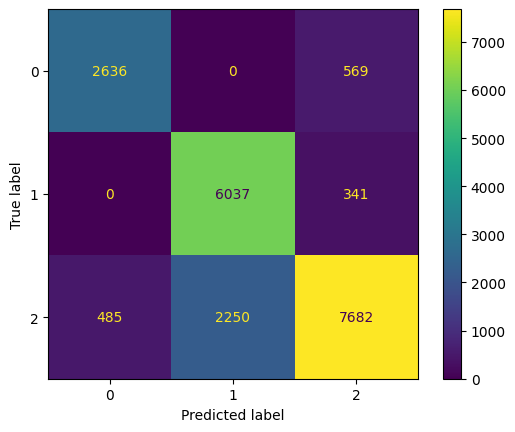

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = gb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [62]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        1          1
1        2          2
2        1          1
3        1          1
4        2          2
5        2          2
6        0          2
7        2          2
8        1          1
9        0          0
10       1          1
11       1          2
12       1          1
13       1          1
14       2          2
15       2          2
16       2          2
17       2          2
18       2          2
19       0          0


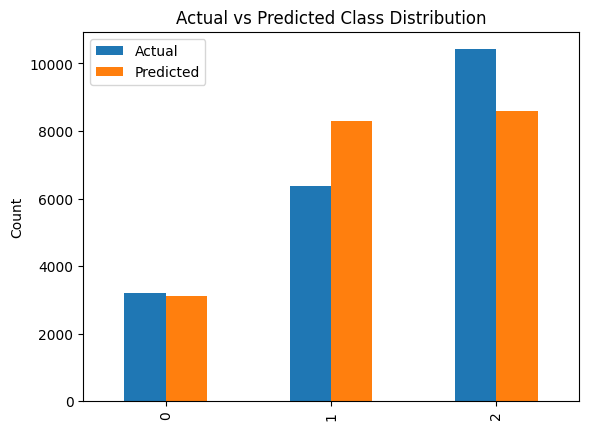

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

df_plot = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
})

df_plot.plot(kind='bar')
plt.title('Actual vs Predicted Class Distribution')
plt.ylabel('Count')
plt.show()

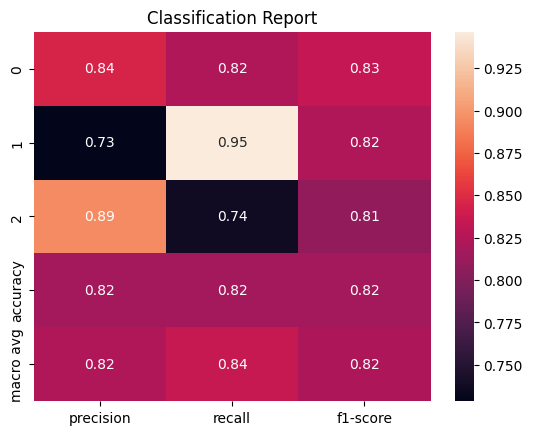

In [64]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

sns.heatmap(report_df.iloc[:-1, :-1], annot=True)
plt.title("Classification Report")
plt.show()